In [1]:
pip install opencv-python ultralytics numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 27.3 MB/s eta 0:00:00


In [4]:
pip install opencv-python matplotlib numpy

Please upload your weld image below:


Saving weld2.jpg to weld2.jpg
Processing: weld2.jpg...


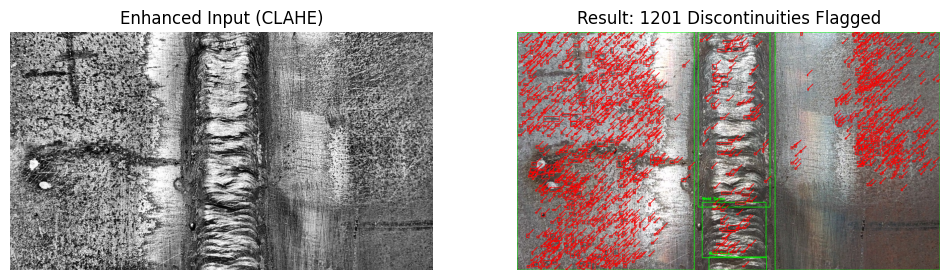

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import io

def detect_weld_in_colab():
    print("Please upload your weld image below:")
    uploaded = files.upload()

    if not uploaded:
        print("No file uploaded.")
        return

    filename = next(iter(uploaded))


    # decode the raw bytes into an OpenCV image
    file_bytes = np.frombuffer(uploaded[filename], dtype=np.uint8)
    img_color = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)
    img_gray = cv2.imdecode(file_bytes, cv2.IMREAD_GRAYSCALE)

    if img_color is None:
        print("Error: Could not decode image.")
        return

    print(f"Processing: {filename}...")

    # Enhances contrast for site-like conditions (smoke/glare)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    enhanced = clahe.apply(img_gray)

    # Gaussian Blur to remove grain/sparks
    blurred = cv2.GaussianBlur(enhanced, (5, 5), 0)

    # Thresholding: Adjust '160' if it misses the weld or selects the floor
    _, weld_mask = cv2.threshold(blurred, 160, 255, cv2.THRESH_BINARY)

    # Fill gaps in the detection
    kernel = np.ones((15,15), np.uint8)
    weld_mask = cv2.morphologyEx(weld_mask, cv2.MORPH_CLOSE, kernel)

    weld_contours, _ = cv2.findContours(weld_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    weld_roi_mask = np.zeros_like(img_gray)
    weld_detected = False

    for cnt in weld_contours:
        if cv2.contourArea(cnt) > 1000: # Filter small noise
            weld_detected = True
            x, y, w, h = cv2.boundingRect(cnt)

            # Draw Green Box (Seam)
            cv2.rectangle(img_color, (x, y), (x+w, y+h), (0, 255, 0), 2)
            cv2.putText(img_color, 'Weld Seam', (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

            # Add to mask so we only search for defects INSIDE the weld
            cv2.drawContours(weld_roi_mask, [cnt], -1, 255, -1)

    if not weld_detected:
        print("Warning: No weld seam detected. (Try lowering the threshold in the code)")

    # Invert image (Dark cracks become bright)
    inverted = cv2.bitwise_not(blurred)

    # Limit search to the weld area
    masked_search = cv2.bitwise_and(inverted, inverted, mask=weld_roi_mask)

    # Threshold for defects (200 = very dark cracks)
    _, defect_mask = cv2.threshold(masked_search, 200, 255, cv2.THRESH_BINARY)

    defect_contours, _ = cv2.findContours(defect_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    defects_found = 0
    for cnt in defect_contours:
        area = cv2.contourArea(cnt)
        if 10 < area < 500: # Filter by size (ignore tiny specks or huge shadows)
            defects_found += 1
            x, y, w, h = cv2.boundingRect(cnt)

            # Draw Red Box (Defect)
            cv2.rectangle(img_color, (x, y), (x+w, y+h), (0, 0, 255), 2)
            # Draw pointer line
            cv2.line(img_color, (x+w, y), (x+w+20, y-20), (0, 0, 255), 2)

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.title("Enhanced Input (CLAHE)")
    plt.imshow(enhanced, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title(f"Result: {defects_found} Discontinuities Flagged")
    plt.imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.show()
if __name__ == "__main__":
    detect_weld_in_colab()